In [24]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
job_array=False;index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [25]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [26]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
with h5py.File(dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5', 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [8]:
#job array setup #UNCOMMENT IF USING JOB_ARRAY
job_array=False
if job_array==True:
    num_jobs=60 #how many total jobs are being run? i.e. array=1-100 ==> num_jobs=100 #***
    job_id = int(os.environ.get('SLURM_ARRAY_TASK_ID', 0)) #this is the current SBATCH job id
    if job_id==0: job_id=1
        
    num_parcels=len(data['time']) #total num of variables
    job_range = num_parcels//num_jobs #number of parcels per job 
    start_job = (job_id - 1) * job_range
    end_job = start_job + job_range
    if job_id==num_jobs: end_job=num_parcels-1
    
    
    #FOR ENTRAINMENT THE PREVIOUS TIMESTEP IS ALWAYS NEEDED, SO SLICED WILL CAUSE WRAP AROUND DATA
    #INSTEAD NP.WHERE RESULTS MUST BE SUBSETTED
    # data=data.isel(time=slice(start_job,end_job))
    # parcel=parcel.isel(time=slice(start_job,end_job))
    
    # #SLICING LAGRANGIAN BINARY ARRAY
    # A_g=A_g[slice(start_job,end_job)]
    # A_c=A_c[slice(start_job,end_job)]
    # Z=Z[slice(start_job,end_job)]
    # Y=Y[slice(start_job,end_job)]
    # X=X[slice(start_job,end_job)]

In [9]:
###########################################################################################################################################################################

In [10]:
#ENTRAINMENT/DETRAINMENT
########################################################################################################

In [12]:
#READING BACK IN
mins_thresh=5
dir3=dir+f'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+f'mins_{res}_{Np_str}.h5'
with h5py.File(dir3, 'r') as h5file:
    A_g_Processed_e = h5file['A_g_Processed_e'][:]
    A_g_Processed_d = h5file['A_g_Processed_d'][:]
    A_c_Processed_e = h5file['A_c_Processed_e'][:]
    A_c_Processed_d = h5file['A_c_Processed_d'][:] 

In [13]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [14]:
#TURN PROCESSING ON OR OFF
PROCESSING=False
PROCESSING=True

def ed(A,z,t,type):
    #Get Z Locations
    zs=Z[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]
    
    #Essentially the I function
    z_ind=np.where(zs==z)
    A_z=D[z_ind]
    
    #Esentially the H function

    if type=='e':
        A_z[A_z<0]=0 #entrainment
    if type=='d':
        A_z[A_z>0]=0 #detrainment

    #Essentially the sumnation
    A_sum=np.sum(A_z)

    if type=='d': 
        A_sum*=-1

    #CONSTANT
    ############
    m_out=m(t)
    dz=zf(z+1)-zf(z)
    constant=(m_out/Lx/Ly/dz/dt) 
    # constant=1
    A_sum*=constant

    #REMOVING THE FIRST TIMESTEP
    if t==0:
        A_sum=0
    return A_sum

#creates 2d storage array
tlen=len(data['time'])
zlen=len(data['zh'])
profile_array_e_g=np.zeros((tlen,zlen))
profile_array_d_g=np.zeros((tlen,zlen))
profile_array_e_c=np.zeros((tlen,zlen))
profile_array_d_c=np.zeros((tlen,zlen))

#Adding to Profile Array
import itertools
ts = range(0, len(data['time']))  # ts from 0 to 140
zs = range(0, len(data['zh']))   # zs from 0 to 34
for count, (t, z) in enumerate(itertools.product(ts, zs)):
    if np.mod(count,1000)==0: print(f'{count*100/len(ts)/len(zs):.2f}%')

    #GENERAL
    if PROCESSING==False:
        A_sum_g=ed(A_g, z,t,type='e'); profile_array_e_g[t,z]+=A_sum_g
        A_sum_g=ed(A_g, z,t,type='d'); profile_array_d_g[t,z]+=A_sum_g
    elif PROCESSING==True:
        A_sum_g=ed(A_g_Processed_e, z,t,type='e'); profile_array_e_g[t,z]+=A_sum_g
        A_sum_g=ed(A_g_Processed_d, z,t,type='d'); profile_array_d_g[t,z]+=A_sum_g

    #CLOUDY
    if PROCESSING==False:
        A_sum_c=ed(A_c, z,t,type='e'); profile_array_e_c[t,z]+=A_sum_c
        A_sum_c=ed(A_c, z,t,type='d'); profile_array_d_c[t,z]+=A_sum_c
    elif PROCESSING==True:
        A_sum_c=ed(A_c_Processed_e, z,t,type='e'); profile_array_e_c[t,z]+=A_sum_c
        A_sum_c=ed(A_c_Processed_d, z,t,type='d'); profile_array_d_c[t,z]+=A_sum_c

#SAVING
if PROCESSING==False:
    dir3=dir+f'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles_{res}_{Np_str}.h5'
if PROCESSING==True:
    dir3=dir+f'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{Np_str}.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
    h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)
    h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
    h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)
print('done')

0.00%
22.11%
44.23%
66.34%
88.46%
done


In [20]:
# #TESTING
# t=100
# zhs=data['zh'].data
# entrain=[];detrain=[]
# for z in np.arange(len(data['zh'])):
#     entrain.append(ed(A_c,z,t,type='e'))
#     detrain.append(ed(A_c,z,t,type='d'))
# plt.plot(entrain,zhs,label='entrain')
# plt.plot(detrain,zhs,label='detrain')
# plt.plot(np.array(entrain)-np.array(detrain),zhs,label='net')


# #TESTING
# t=100
# entrain=[];detrain=[]
# for z in np.arange(len(data['zh'])):
#     entrain.append(ed(A_c_Processed_e,z,t,type='e'))
#     detrain.append(ed(A_c_Processed_d,z,t,type='d'))
# plt.plot(entrain,zhs,label='entrain pp',linestyle='dashed')
# plt.plot(detrain,zhs,label='detrain pp',linestyle='dashed')
# plt.plot(np.array(entrain)-np.array(detrain),zhs,linestyle='dashed',label='net pp')

# plt.legend();plt.title(f'Testing No Preprocessing VS Preprocessing for t = {t}')
# plt.axvline(0,color='k')

In [21]:
# #TESTING
# t=100
# zhs=data['zh'].data
# entrain=[];detrain=[]
# for z in np.arange(len(data['zh'])):
#     entrain.append(ed(A_g,z,t,type='e'))
#     detrain.append(ed(A_g,z,t,type='d'))
# plt.plot(entrain,zhs,label='entrain')
# plt.plot(detrain,zhs,label='detrain')
# plt.plot(np.array(entrain)-np.array(detrain),zhs,label='net')


# #TESTING
# t=100
# entrain=[];detrain=[]
# for z in np.arange(len(data['zh'])):
#     entrain.append(ed(A_g_Processed_e,z,t,type='e'))
#     detrain.append(ed(A_g_Processed_d,z,t,type='d'))
# plt.plot(entrain,zhs,label='entrain pp',linestyle='dashed')
# plt.plot(detrain,zhs,label='detrain pp',linestyle='dashed')
# plt.plot(np.array(entrain)-np.array(detrain),zhs,linestyle='dashed',label='net pp')

# plt.legend();plt.title(f'Testing No Preprocessing VS Preprocessing for t = {t}')
# plt.axvline(0,color='k')

# ax=[plt.gca()];apply_scientific_notation(ax)

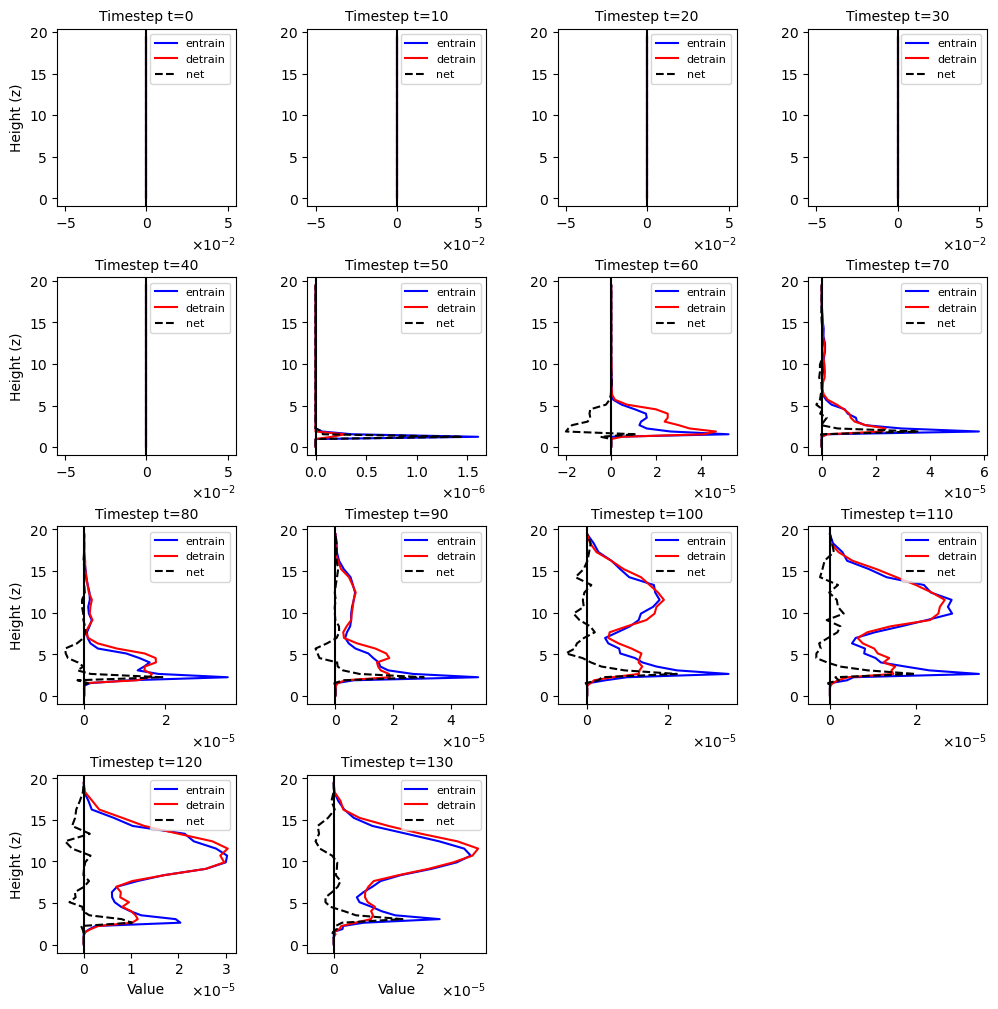

In [22]:
#TESTING
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

Nt = len(data['time'])
timesteps = np.arange(0, Nt, 10)  # Every 10 timesteps

nrows, ncols = 4, 4  # Define a 4x4 grid
fig = plt.figure(figsize=(12, 12))  # Square figure for better layout
gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.4, hspace=0.4)  # Adjust spacing

zhs = data['zh'].data

for i, t in enumerate(timesteps[:nrows * ncols]):  # Limit to 16 plots (4x4)
    entrain = []
    detrain = []

    for z in range(len(zhs)):
        entrain.append(ed(A_c, z, t, type='e'))
        detrain.append(ed(A_c, z, t, type='d'))

    row, col = i // ncols, i % ncols  # Calculate subplot position
    ax = fig.add_subplot(gs[row, col])

    ax.plot(entrain, zhs, label='entrain', color='b')
    ax.plot(detrain, zhs, label='detrain', color='r')
    ax.plot(np.array(entrain) - np.array(detrain), zhs, linestyle='dashed', label='net', color='k')

    ax.set_title(f"Timestep t={t}", fontsize=10)

    if row == nrows - 1:
        ax.set_xlabel("Value")
    if col == 0:
        ax.set_ylabel("Height (z)")

    ax.legend(fontsize=8, loc='upper right')

    ax.axvline(0,color='k')

    apply_scientific_notation([ax])


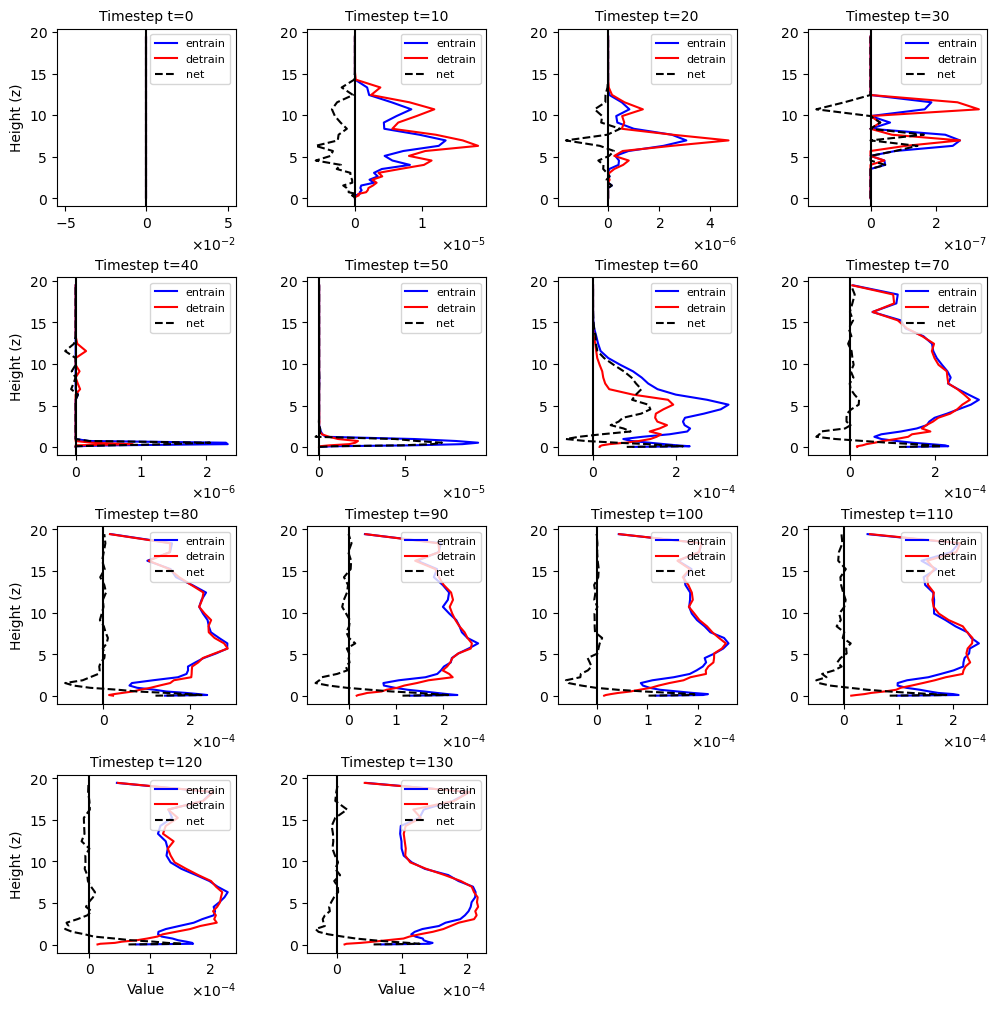

In [23]:
#TESTING
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

Nt = len(data['time'])
timesteps = np.arange(0, Nt, 10)  # Every 10 timesteps

nrows, ncols = 4, 4  # Define a 4x4 grid
fig = plt.figure(figsize=(12, 12))  # Square figure for better layout
gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.4, hspace=0.4)  # Adjust spacing

zhs = data['zh'].data

for i, t in enumerate(timesteps[:nrows * ncols]):  # Limit to 16 plots (4x4)
    entrain = []
    detrain = []

    for z in range(len(zhs)):
        entrain.append(ed(A_g, z, t, type='e'))
        detrain.append(ed(A_g, z, t, type='d'))

    row, col = i // ncols, i % ncols  # Calculate subplot position
    ax = fig.add_subplot(gs[row, col])

    ax.plot(entrain, zhs, label='entrain', color='b')
    ax.plot(detrain, zhs, label='detrain', color='r')
    ax.plot(np.array(entrain) - np.array(detrain), zhs, linestyle='dashed', label='net', color='k')

    ax.set_title(f"Timestep t={t}", fontsize=10)

    if row == nrows - 1:
        ax.set_xlabel("Value")
    if col == 0:
        ax.set_ylabel("Height (z)")

    ax.legend(fontsize=8, loc='upper right')

    ax.axvline(0,color='k')

    apply_scientific_notation([ax])



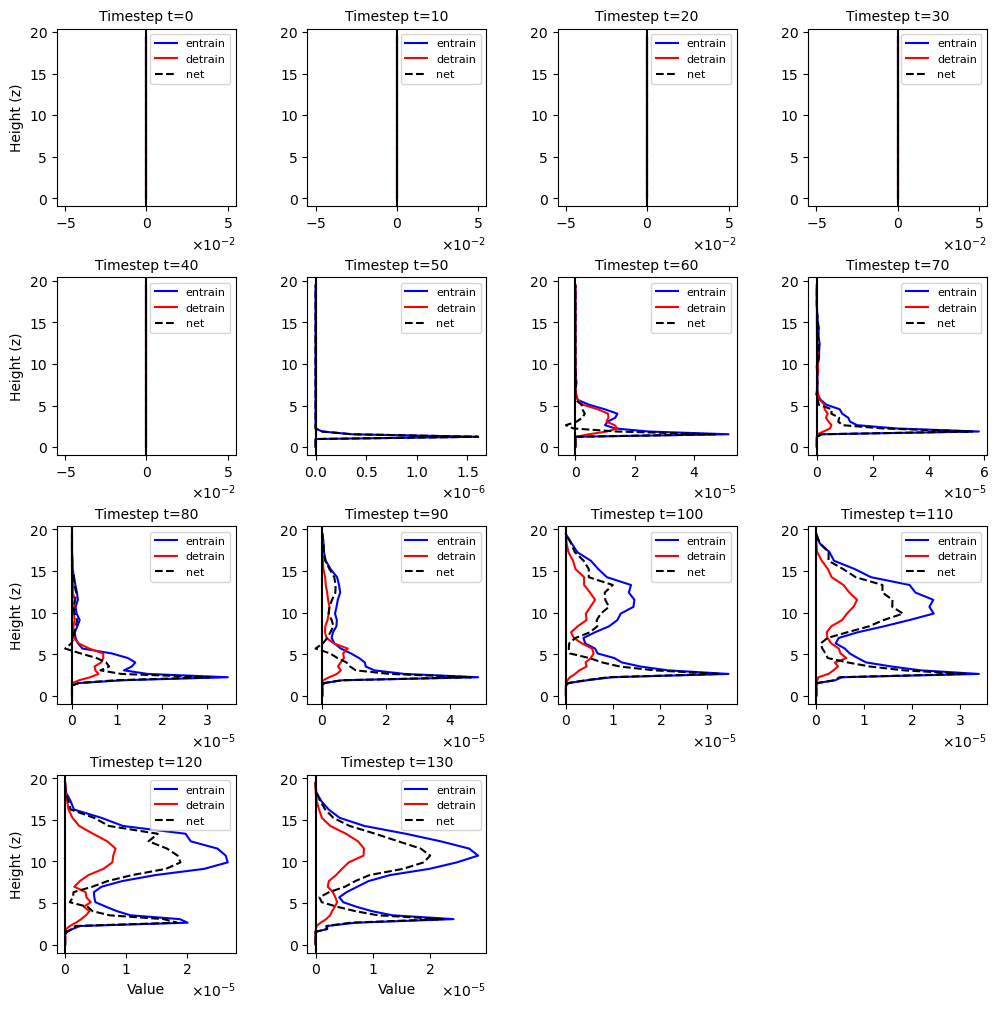

In [24]:
#TESTING
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

Nt = len(data['time'])
timesteps = np.arange(0, Nt, 10)  # Every 10 timesteps

nrows, ncols = 4, 4  # Define a 4x4 grid
fig = plt.figure(figsize=(12, 12))  # Square figure for better layout
gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.4, hspace=0.4)  # Adjust spacing

zhs = data['zh'].data

for i, t in enumerate(timesteps[:nrows * ncols]):  # Limit to 16 plots (4x4)
    entrain = []
    detrain = []

    for z in range(len(zhs)):
        entrain.append(ed(A_c_Processed_e, z, t, type='e'))
        detrain.append(ed(A_c_Processed_d, z, t, type='d'))

    row, col = i // ncols, i % ncols  # Calculate subplot position
    ax = fig.add_subplot(gs[row, col])

    ax.plot(entrain, zhs, label='entrain', color='b')
    ax.plot(detrain, zhs, label='detrain', color='r')
    ax.plot(np.array(entrain) - np.array(detrain), zhs, linestyle='dashed', label='net', color='k')

    ax.set_title(f"Timestep t={t}", fontsize=10)

    if row == nrows - 1:
        ax.set_xlabel("Value")
    if col == 0:
        ax.set_ylabel("Height (z)")

    ax.legend(fontsize=8, loc='upper right')

    ax.axvline(0,color='k')

    apply_scientific_notation([ax])



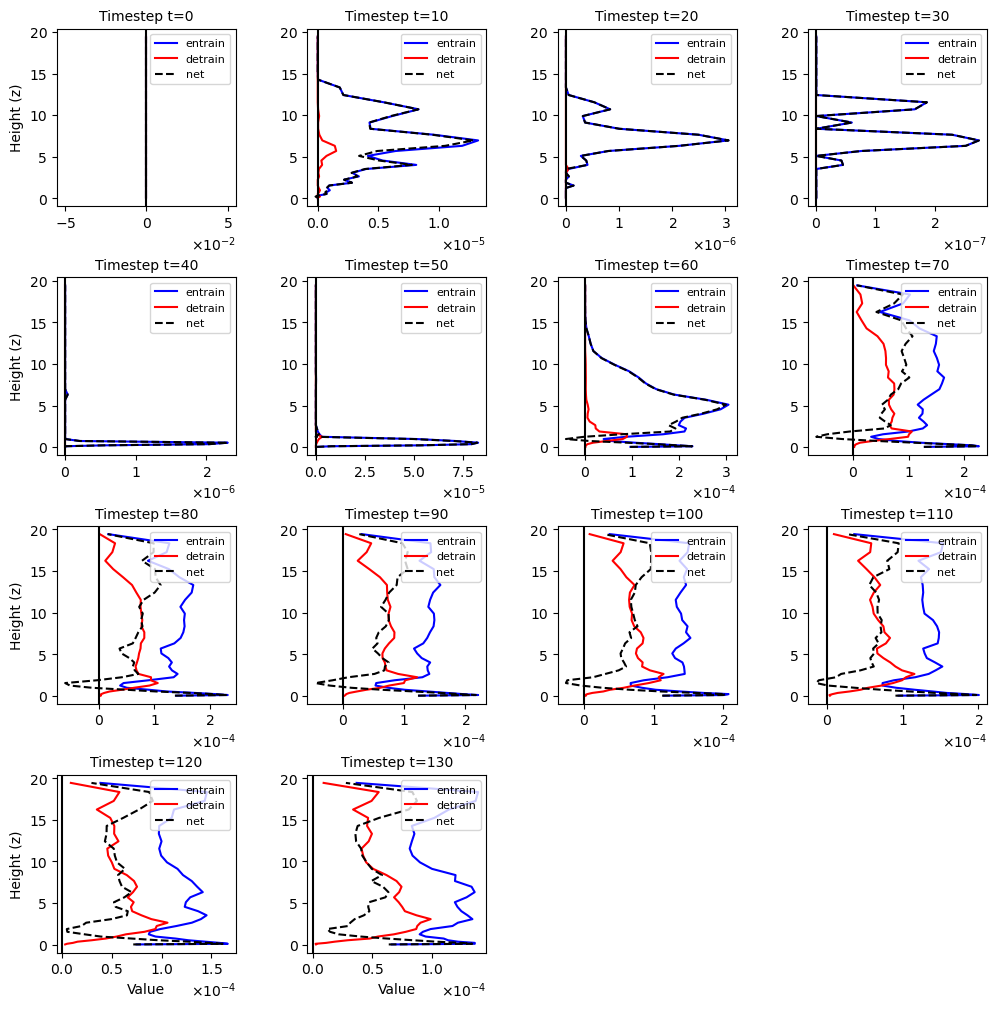

In [25]:
#TESTING
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

Nt = len(data['time'])
timesteps = np.arange(0, Nt, 10)  # Every 10 timesteps

nrows, ncols = 4, 4  # Define a 4x4 grid
fig = plt.figure(figsize=(12, 12))  # Square figure for better layout
gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.4, hspace=0.4)  # Adjust spacing

zhs = data['zh'].data

for i, t in enumerate(timesteps[:nrows * ncols]):  # Limit to 16 plots (4x4)
    entrain = []
    detrain = []

    for z in range(len(zhs)):
        entrain.append(ed(A_g_Processed_e, z, t, type='e'))
        detrain.append(ed(A_g_Processed_d, z, t, type='d'))

    row, col = i // ncols, i % ncols  # Calculate subplot position
    ax = fig.add_subplot(gs[row, col])

    ax.plot(entrain, zhs, label='entrain', color='b')
    ax.plot(detrain, zhs, label='detrain', color='r')
    ax.plot(np.array(entrain) - np.array(detrain), zhs, linestyle='dashed', label='net', color='k')

    ax.set_title(f"Timestep t={t}", fontsize=10)

    if row == nrows - 1:
        ax.set_xlabel("Value")
    if col == 0:
        ax.set_ylabel("Height (z)")

    ax.legend(fontsize=8, loc='upper right')

    ax.axvline(0,color='k')

    apply_scientific_notation([ax])



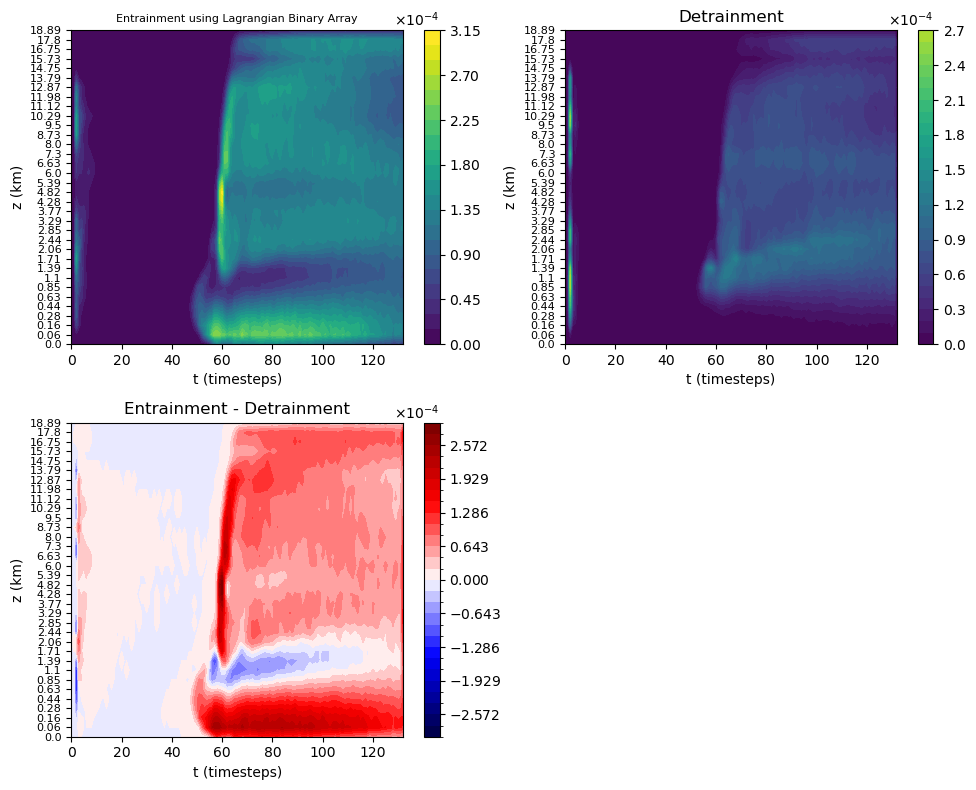

In [32]:
PROCESSING=False
PROCESSING=True

type='general'
# type='cloudy'

if PROCESSING==False:
    dir3=dir+f'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles_{res}_{Np_str}.h5'
if PROCESSING==True:
    dir3=dir+f'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{Np_str}.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

if type=='general':
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type=='cloudy':
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######

######
vmax_shared = np.max([np.max(profile_array_e), np.max(profile_array_d)])
norm_shared = mcolors.Normalize(vmin=0, vmax=vmax_shared)
######

# First subplot: Entrainment
########################################
ax1 = fig.add_subplot(gs[0, 0])
# contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1)
contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
cbar1=fig.colorbar(contour1, ax=ax1)
Nz = len(data['zh'])
ax1.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax1.set_ylabel('z (km)');ax1.set_xlabel('t (timesteps)')
ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=8)

# Second subplot: Detrainment
########################################
ax2 = fig.add_subplot(gs[0, 1])
# contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1)
contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
cbar2 = fig.colorbar(contour2, ax=ax2)
ax2.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax2.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax2.set_ylabel('z (km)');ax2.set_xlabel('t (timesteps)')
ax2.set_title('Detrainment')

# Third subplot: Net Entrainment
########################################
profile_array_net=profile_array_e-profile_array_d

# #OLD METHOD, DOESNT BALANCE COLOR LEVELS
# # Normalize with a balanced vmin and vmax
# levels=49; vmin=np.min(profile_array_net);vmax=np.max(profile_array_net)
# # vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
# norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Normalize with a balanced vmin and vmax
vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
levels = np.linspace(vmin, vmax, n_levels)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
cmap = plt.get_cmap('RdBu_r', n_levels)

ax3 = fig.add_subplot(gs[1, 0])
contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, norm=norm, levels=levels)
# contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, levels=30,vmin=-np.max(abs(profile_array_net)), vmax=+np.max(abs(profile_array_net)))
# cmap2 = plt.get_cmap('RdBu', 29);contour3 = ax3.pcolor(profile_array_net.T, cmap=cmap2, norm=norm, shading='auto')
cbar3 = fig.colorbar(contour3, ax=ax3, norm=norm)

#FIXING TICKS
ax3.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax3.set_ylabel('z (km)');ax3.set_xlabel('t (timesteps)')
ax3.set_title('Entrainment - Detrainment')

#FIXING SCIENTIFIC NOTATION
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
for cbar in (cbar1,cbar2, cbar3):  # These must be Colorbar instances
    cbar.formatter = formatter
    cbar.update_ticks()

# Display the plot
plt.tight_layout()

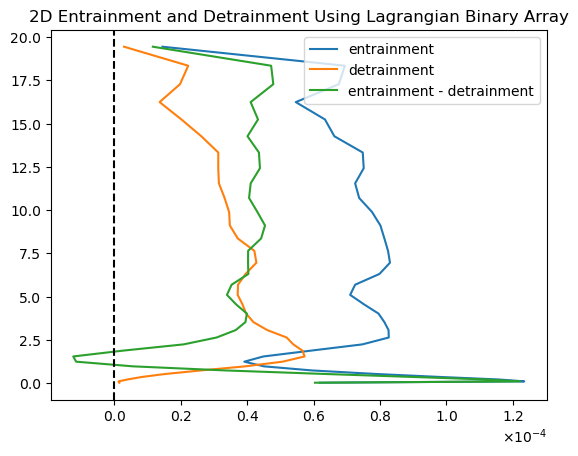

In [33]:
plt.plot(np.mean(profile_array_e,axis=(0)),data['zh'],label='entrainment')
plt.plot(np.mean(profile_array_d,axis=(0)),data['zh'],label='detrainment')
plt.plot(np.mean(profile_array_e-profile_array_d,axis=(0)),data['zh'],label='entrainment - detrainment')
plt.axvline(0,color='k',linestyle='dashed')

plt.legend(); plt.title('2D Entrainment and Detrainment Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)

In [21]:
############## 3D ENTRAINMENT

In [42]:
#READING BACK IN
mins_thresh=5
# mins_thresh=10
dir3=dir+'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+'mins.h5'
with h5py.File(dir3, 'r') as h5file:
    A_g_Processed_e = h5file['A_g_Processed_e'][:]
    A_g_Processed_d = h5file['A_g_Processed_d'][:]
    A_c_Processed_e = h5file['A_c_Processed_e'][:]
    A_c_Processed_d = h5file['A_c_Processed_d'][:]

In [85]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item() #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item() #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [86]:
def ed3d(A,t,z,y,x,type):
    #Get Z Locations
    zs=Z[t,:]
    ys=Y[t,:]
    xs=X[t,:]
    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]
    
    #Essentially the I function
    zyx_ind=np.where((zs==z)&(ys==y)&(xs==x))
    A_z=D[zyx_ind]
    
    #Esentially the H function

    if type=='e':
        A_z[A_z<0]=0 #entrainment
    if type=='d':
        A_z[A_z>0]=0 #detrainment

    #Essentially the sumnation
    A_sum=np.sum(A_z)

    if type=='d': 
        A_sum*=-1

    #CONSTANT
    ############
    m_out=m(t)
    dz=zf(z+1)-zf(z);dy=1000;dx=1000
    constant=(m_out/dx/dy/dz/dt) 
    # constant=1
    A_sum*=constant

    #REMOVING THE FIRST TIMESTEP
    if t==0:
        A_sum=0
    return A_sum

In [36]:
# #LOADING VARIABLES
# if 'emptylike' not in globals():
#     print('loading neccessary variables')
#     variable='w'; w_data=data[variable] #get w data
#     w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
#     # variable='qv'; qv_data=data[variable].data # get qc data
#     variable='qc'; qc_data=data[variable].data # get qc data
#     variable='qi'; qi_data=data[variable].data # get qc data
#     qc_plus_qi=qc_data+qi_data

#     print('done loading')
#     emptylike=True

loading neccessary variables
done loading


In [4]:
def call_variables(t): 
    if np.mod(t,25)==0: print(f'loading variables for time {t}')
    variable='w'; w_data=data[variable].isel(time=t).interp(zf=data['zh']).data #get w_data and interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].isel(time=t).data # get qc data
    variable='qc'; qc_data=data[variable].isel(time=t).data # get qc data
    variable='qi'; qi_data=data[variable].isel(time=t).data # get qc data
    qc_plus_qi=qc_data+qi_data
    variable='th'; th_data=data[variable].isel(time=t).data # get qc data
    variable='buoyancy'; buoyancy_data=data[variable].isel(time=t).data # get qc data
    
    import h5py
    with h5py.File(dir + 'Variable_Calculation/' + 'theta_e'+f'_{res}'+'.h5', 'r') as f:
        theta_e_data = f['theta_e'][t]

    return w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data

In [7]:
#Eulerian General and Cloudy Updrafts
##############
def get_indices_g(w_thresh1,qcqi_thresh,type):
        
    where1g_all_t = []  # List to collect indices for each time step
    where1g_all_z = []
    where1g_all_y = []
    where1g_all_x = []
    
    Nt = len(data['time'])
    for t in range(Nt):  
        [w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data] = call_variables(t)  # Load variables for time t

        if type=='e':
            where1g_t = np.where((w_data>=w_thresh1)&(qc_plus_qi<qcqi_thresh))
        if type=='d':
            where1g_t = np.where((w_data<w_thresh1)|(qc_plus_qi>=qcqi_thresh))
        
        if where1g_t[0].size > 0:  # Ensure non-empty results
            where1g_all_t.append(np.full_like(where1g_t[0], t))  # Create time index array
            where1g_all_z.append(where1g_t[0])  # z indices
            where1g_all_y.append(where1g_t[1])  # y indices
            where1g_all_x.append(where1g_t[2])  # x indices
    
    # Convert lists to numpy arrays and concatenate
    where1g = (
        np.concatenate(where1g_all_t),
        np.concatenate(where1g_all_z),
        np.concatenate(where1g_all_y),
        np.concatenate(where1g_all_x)
    )
    return where1g


#Eulerian General and Cloudy Updrafts
##############

def get_indices_c(w_thresh2,qcqi_thresh,type):
    
    where1c_all_t = []  # List to collect indices for each time step
    where1c_all_z = []
    where1c_all_y = []
    where1c_all_x = []
    
    Nt = len(data['time'])
    for t in range(Nt):  
        [w_data,qv_data,qc_data,qi_data,qc_plus_qi,th_data,buoyancy_data,theta_e_data] = call_variables(t)  # Load variables for time t

        if type=='e':
            where1c_t = np.where((w_data >= w_thresh2) & (qc_plus_qi >= qcqi_thresh))
        if type=='d':
            where1c_t = np.where((w_data < w_thresh2) | (qc_plus_qi < qcqi_thresh))
        
        if where1c_t[0].size > 0:  # Ensure non-empty results
            where1c_all_t.append(np.full_like(where1c_t[0], t))  # Create time index array
            where1c_all_z.append(where1c_t[0])  # z indices
            where1c_all_y.append(where1c_t[1])  # y indices
            where1c_all_x.append(where1c_t[2])  # x indices
    
    # Convert lists to numpy arrays and concatenate
    where1c = (
        np.concatenate(where1c_all_t),
        np.concatenate(where1c_all_z),
        np.concatenate(where1c_all_y),
        np.concatenate(where1c_all_x)
    )
    return where1c

#TESTING
# w_thresh1=0.1
# qcqi_thresh=1e-6
# indices=np.where((w_data>=w_thresh1)&(qc_plus_qi<qcqi_thresh)) #USE IF LOADING FULL VARIABLE
# one=indices
# indices = get_indices_g(w_thresh1,qcqi_thresh,type='e') #USE IF LOADING TIMESTEP BY TIMESTEP
# two=indices
# np.all((one[0]==two[0])==True)

In [9]:
#JOB ARRAY FOR SUBSETTING NP.WHERE OUTPUTS
def job_subset_where(where):
    array1, array2, array3, array4 = where
    mask = (array1 >= start_job) & (array1 < end_job)
    filtered_data = tuple(arr[mask] for arr in where) #USE IN INITIALIZING FULL ARRAY EACH TIME
    return filtered_data

In [65]:
#TURN PROCESSING ON OR OFF
PROCESSING=False
PROCESSING=True

#SET UP TO RUN WITH JOB_ARRAY
calc_entrain=False
calc_detrain=False

#creates 2d storage array

# tlen=len(data['time'])
tlen=end_job-start_job
zlen=len(data['zh'])
ylen=len(data['yh'])
xlen=len(data['xh'])

profile_array_e_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_e_c=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_c=np.zeros((tlen,zlen,ylen,xlen))
    
#Adding to Profile Array
# import itertools
# ts = range(0, 141)  # ts from 0 to 140
# zs = range(0, 34)   # zs from 0 to 34
# for count, (t, z) in enumerate(itertools.product(ts, zs)):

#GENERAL UPDRAFTS

#ENTRAINMENT
if calc_entrain==True:
    w_thresh1=0.1
    qcqi_thresh=1e-6
    # indices=np.where((w_data>=w_thresh1)&(qc_plus_qi<qcqi_thresh)) #USE IF LOADING FULL VARIABLE
    indices = get_indices_g(w_thresh1,qcqi_thresh,type='e') #USE IF LOADING TIMESTEP BY TIMESTEP
    
    indices_e=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_e)==True:
        tmin=np.min(indices_e[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_e)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_e[0]):.2f}%')

        if PROCESSING==False:
            A_sum_e_g=ed3d(A_g,t,z,y,x,type='e')
        elif PROCESSING==True:
            A_sum_e_g=ed3d(A_g_Processed_e,t,z,y,x,type='e') #PROCESSING
        
        # profile_array_e_g[t,z,y,x]+=A_sum_e_g #WITHOUT JOB_ARRAY
        profile_array_e_g[t-tmin,z,y,x]+=A_sum_e_g #CORRECT FOR JOB_ARRAY

#DETRAINMENT
if calc_detrain==True:
    w_thresh1=0.1
    qcqi_thresh=1e-6
    # indices=np.where((w_data<w_thresh1)| (qc_plus_qi>=qcqi_thresh)) #NEGATION OF THRESHOLD
    indices = get_indices_g(w_thresh1,qcqi_thresh,type='d') #USE IF LOADING TIMESTEP BY TIMESTEP
    indices_d=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_d)==True:
        tmin=np.min(indices_d[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_d)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_d[0]):.2f}%')

        if PROCESSING==False:
            A_sum_d_g=ed3d(A_g,t,z,y,x,type='d')
        elif PROCESSING==True:
            A_sum_d_g=ed3d(A_g_Processed_d,t,z,y,x,type='d') #PROCESSING
        
        # profile_array_d_g[t,z,y,x]+=A_sum_d_g #WITHOUT JOB_ARRAY
        profile_array_d_g[t-tmin,z,y,x]+=A_sum_d_g #CORRECT FOR JOB_ARRAY


#CLOUDY UPDRAFTS

#ENTRAINMENT
if calc_entrain==True:
    w_thresh2=0.5
    qcqi_thresh=1e-6
    # indices=np.where((w_data>=w_thresh2)&(qc_plus_qi>=qcqi_thresh)) #USE IF LOADING FULL VARIABLE
    indices=get_indices_c(w_thresh2,qcqi_thresh,type='e') 

    indices_e=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    if np.any(indices_e)==True:
        tmin=np.min(indices_e[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_e)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_e[0]):.2f}%')

        if PROCESSING==False:
            A_sum_e_c=ed3d(A_c,t,z,y,x,type='e') 
        elif PROCESSING==True:
            A_sum_e_c=ed3d(A_c_Processed_e,t,z,y,x,type='e') #PROCESSING

        
        # profile_array_e_c[t,z,y,x]+=A_sum_e_c #WITHOUT JOB_ARRAY
        profile_array_e_c[t-tmin,z,y,x]+=A_sum_e_c #CORRECT FOR JOB_ARRAY


#DETRAINMENT
if calc_detrain==True:
    w_thresh2=0.5
    qcqi_thresh=1e-6
    # indices=np.where((w_data<w_thresh2)|(qc_plus_qi<qcqi_thresh))
    indices=get_indices_c(w_thresh2,qcqi_thresh,type='d') 
    indices_d=job_subset_where(indices) #USE FOR JOB_ARRAY ONLY***
    
    
    if np.any(indices_d)==True:
        tmin=np.min(indices_d[0]) #USE FOR JOB_ARRAY ONLY***
    else: 
        tmin=0
    for count, (t, z, y, x) in enumerate(zip(*indices_d)):
        if np.mod(count,10000)==0: print(f'{count*100/len(indices_d[0]):.2f}%')

        if PROCESSING==False:
            A_sum_d_c=ed3d(A_c,t,z,y,x,type='d')
        elif PROCESSING==True:
            A_sum_d_c=ed3d(A_c_Processed_d,t,z,y,x,type='d')
        
        # profile_array_d_c[t,z,y,x]+=A_sum_d_c #WITHOUT JOB_ARRAY
        profile_array_d_c[t-tmin,z,y,x]+=A_sum_d_c #CORRECT FOR JOB_ARRAY


#SAVING
if calc_entrain==True:
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_entrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "w") as h5f:
        h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
        h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)
if calc_detrain==True:
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_detrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "w") as h5f:
        h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
        h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)

0.00%


In [3]:
#RECOMBING DATA AFTERWARDS
#######################################################
#COMBINING JOB_ARRAYS (RUN AFTER ALL JOB_ARRAYS ARE FINISHED)

tlen=len(netCDF['time'])
zlen=len(netCDF['zh'])
ylen=len(netCDF['yh'])
xlen=len(netCDF['xh'])
profile_array_e_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_g=np.zeros((tlen,zlen,ylen,xlen))
profile_array_e_c=np.zeros((tlen,zlen,ylen,xlen))
profile_array_d_c=np.zeros((tlen,zlen,ylen,xlen))

#ENTRAINMENT
tlen1=0
for job_id in np.arange(1,60+1):
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_entrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "r") as h5f:
        tlen2=tlen1+h5f["profile_array_e_g"][:].shape[0]
        print(tlen1,tlen2)

        profile_array_e_g[tlen1:tlen2] = h5f["profile_array_e_g"][:]
        profile_array_e_c[tlen1:tlen2] = h5f["profile_array_e_c"][:]

        tlen1=tlen2

#SAVING
dir3=dir+f'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
    h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)

#DETRAINMENT
tlen1=0
for job_id in np.arange(1,60+1):
    dir3=dir+f'Project_Algorithms/Entrainment/job_out/3D_detrainment_profiles{job_id}.h5'
    with h5py.File(dir3, "r") as h5f:
        tlen2=tlen1+h5f["profile_array_d_g"][:].shape[0]
        print(tlen1,tlen2)

        profile_array_d_g[tlen1:tlen2] = h5f["profile_array_d_g"][:]
        profile_array_d_c[tlen1:tlen2] = h5f["profile_array_d_c"][:]

        tlen1=tlen2

#SAVING
dir3=dir+f'Project_Algorithms/Entrainment/3D_detrainment_profiles.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
    h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)

0 2
2 4
4 6
6 8
8 10
10 12
12 14
14 16
16 18
18 20
20 22
22 24
24 26
26 28
28 30
30 32
32 34
34 36
36 38
38 40
40 42
42 44
44 46
46 48
48 50
50 52
52 54
54 56
56 58
58 60
60 62
62 64
64 66
66 68
68 70
70 72
72 74
74 76
76 78
78 80
80 82
82 84
84 86
86 88
88 90
90 92
92 94
94 96
96 98
98 100
100 102
102 104
104 106
106 108
108 110
110 112
112 114
114 116
116 118
0 2
2 4
4 6
6 8
8 10
10 12
12 14
14 16
16 18
18 20
20 22
22 24
24 26
26 28
28 30
30 32
32 34
34 36
36 38
38 40
40 42
42 44
44 46
46 48
48 50
50 52
52 54
54 56
56 58
58 60
60 62
62 64
64 66
66 68
68 70
70 72
72 74
74 76
76 78
78 80
80 82
82 84
84 86
86 88
88 90
90 92
92 94
94 96
96 98
98 100
100 102
102 104
104 106
106 108
108 110
110 112
112 114
114 116
116 118


In [4]:
#######################################################
#READING BACK IN 
dir3=dir+'Project_Algorithms/Entrainment/3D_entrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
dir3=dir+'Project_Algorithms/Entrainment/3D_detrainment_profiles.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

In [5]:
#TEMPORARY SUBSET ENTRAINMENT
#DOMAIN SUBSETTING
where_coast_xh=np.where(data['xh']>=0)[0][0]
where_coast_xf=np.where(data['xf']>=0)[0][0]
end_xh=len(data['xh'])-1-50
end_xf=len(data['xf'])-1-50
print(f'x in {0}:{where_coast_xh-1} FOR SEA')
print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
# 6:30==>12*6+6=78
t_end=78
print(f't in {0}:{t_end} (6.5 hours)')
#SUBSETTING CODE
# OCEAN=data.isel(time=slice(0,78+1),xh=slice(0,where_coast_xh+1),xf=slice(0,where_coast_xf+1))
# .isel(time=slice(0,78+1),xh=slice(where_coast_xh,end_xh+1),xf=slice(where_coast_xf,end_xf+1))
#LAND
profile_array_e_g=profile_array_e_g[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
profile_array_d_g=profile_array_d_g[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
profile_array_e_c=profile_array_e_c[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]
profile_array_d_c=profile_array_d_c[slice(0,78+1),:,:,slice(where_coast_xh,end_xh+1)]

x in 0:255 FOR SEA
x in 256:461 FOR LAND
t in 0:78 (6.5 hours)


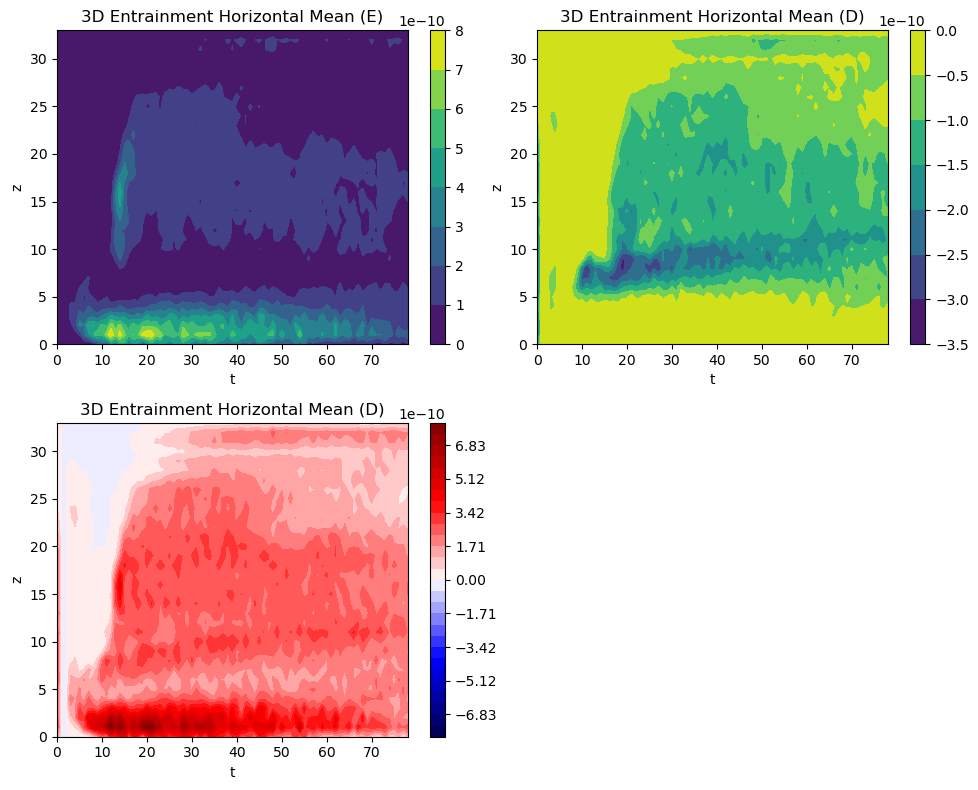

In [12]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######

type='general'
# type='cloudy'

if type=="general":
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type=="cloudy":
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c


ax1 = fig.add_subplot(gs[0, 0])
out = np.mean(profile_array_e, axis=(2, 3))
cf1 = ax1.contourf(out.T, cmap=cmap1)
fig.colorbar(cf1, ax=ax1, orientation='vertical')
ax1.set_title('3D Entrainment Horizontal Mean (E)')
ax1.set_xlabel('t')
ax1.set_ylabel('z')

ax2 = fig.add_subplot(gs[0, 1])
out = np.mean(profile_array_d, axis=(2, 3))
cf2 = ax2.contourf(out.T, cmap=cmap1)
fig.colorbar(cf2, ax=ax2, orientation='vertical')
ax2.set_title('3D Entrainment Horizontal Mean (D)')
ax2.set_xlabel('t')
ax2.set_ylabel('z')


ax3 = fig.add_subplot(gs[1, 0])
profile_array_net = np.mean(profile_array_e-profile_array_d, axis=(2, 3))

# # Normalize with a balanced vmin and vmax
# profile_array_net=out
# vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
# levels = np.linspace(vmin, vmax, n_levels)
# norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
# cf3 = ax3.contourf(out.T, cmap=cmap2,norm=norm,levels=levels)

vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
levels = np.linspace(vmin, vmax, n_levels)

cf3 = ax3.contourf(profile_array_net.T, cmap=cmap2,vmin=vmin,vmax=vmax,levels=levels)
fig.colorbar(cf3, ax=ax3, orientation='vertical')
ax3.set_title('3D Entrainment Horizontal Mean (D)')
ax3.set_xlabel('t')
ax3.set_ylabel('z')

plt.tight_layout()

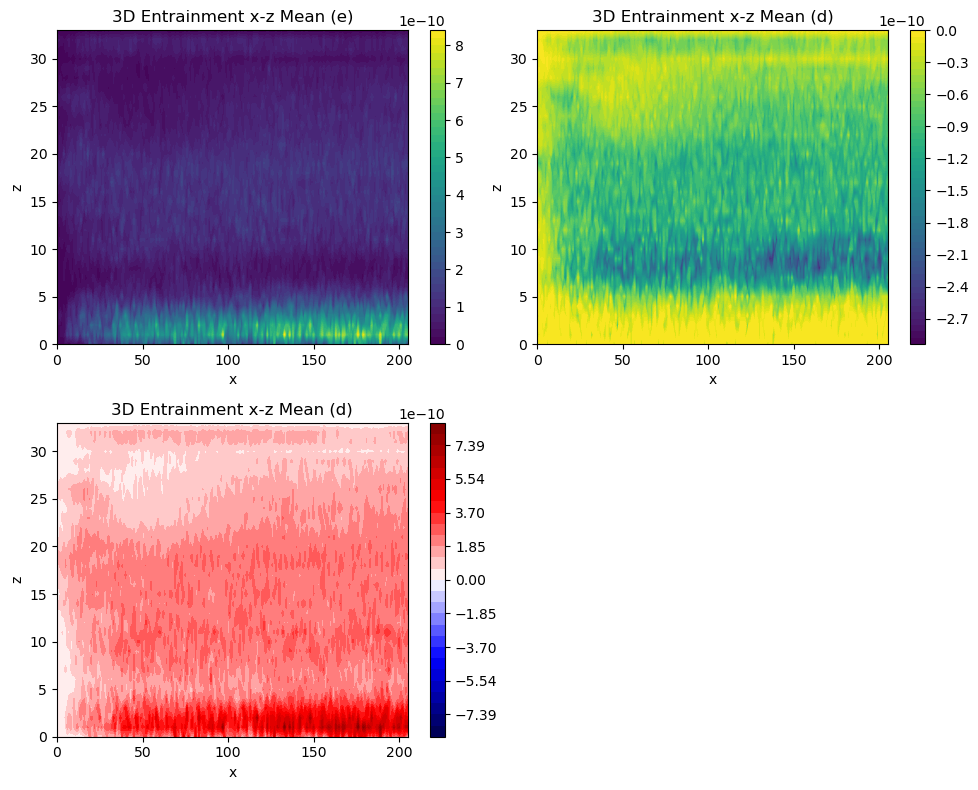

In [13]:
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######

ax1 = fig.add_subplot(gs[0, 0])
out = np.mean(profile_array_e, axis=(0, 2))
cf1 = ax1.contourf(out, levels=50, cmap=cmap1)
fig.colorbar(cf1, ax=ax1, orientation='vertical')
ax1.set_title('3D Entrainment x-z Mean (e)')
ax1.set_xlabel('x')
ax1.set_ylabel('z')

ax2 = fig.add_subplot(gs[0, 1])
out = np.mean(profile_array_d, axis=(0, 2))
cf2 = ax2.contourf(out, levels=50, cmap=cmap1)
fig.colorbar(cf2, ax=ax2, orientation='vertical')
ax2.set_title('3D Entrainment x-z Mean (d)')
ax2.set_xlabel('x')
ax2.set_ylabel('z')


profile_array_net=np.mean(profile_array_e-profile_array_d,axis=(0,2))
nlevel = 29
vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
levels = np.linspace(vmin, vmax, nlevel)

ax3 = fig.add_subplot(gs[1, 0])
cf3 = ax3.contourf(profile_array_net, levels=levels, vmin=vmin,vmax=vmax,cmap=cmap2)
fig.colorbar(cf3, ax=ax3, orientation='vertical')
ax3.set_title('3D Entrainment x-z Mean (d)')
ax3.set_xlabel('x')
ax3.set_ylabel('z')

plt.tight_layout()

# for axis in [ax1,ax2,ax3]:
#     axis.set_xlim(left=-where_coast_xh)

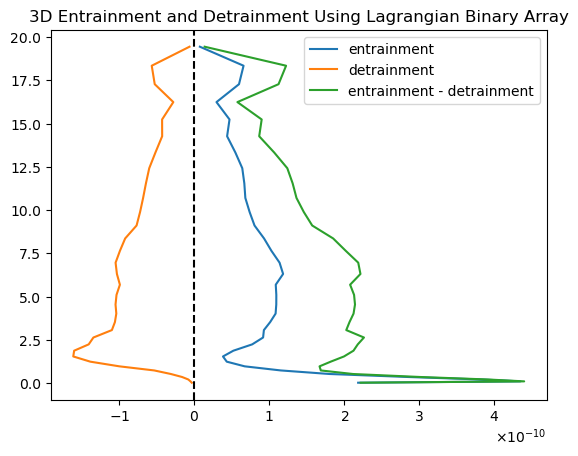

In [14]:
correction=1000**2
correction=1

plt.plot(np.mean(profile_array_e,axis=(0,2,3))*correction,data['zh'],label='entrainment')
plt.plot(np.mean(profile_array_d,axis=(0,2,3))*correction,data['zh'],label='detrainment')
plt.plot(np.mean(profile_array_e-profile_array_d,axis=(0,2,3))*correction,data['zh'],label='entrainment - detrainment')
# plt.plot(np.mean(profile_array_e_c,axis=(0,2,3))*correction,data['zh'],label='entrainment')
# plt.plot(np.mean(profile_array_d_c,axis=(0,2,3))*correction,data['zh'],label='detrainment')
# plt.plot(np.mean((profile_array_e_c-profile_array_d_c)*correction,axis=(0,2,3)),data['zh'],label='entrainment - detrainment')


plt.axvline(0,color='k',linestyle='dashed')

plt.legend(); plt.title('3D Entrainment and Detrainment Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)